# Publication Screening on Single Case Design Research

---

In [ ]:
from datetime import datetime
date = datetime.now()
formatted_date = date.strftime("%B %d, %Y")
print(formatted_date)

February 28, 2026


## 0. Configuring the System Environment

In [ ]:
# Check GPU memory
!nvidia-smi

Sat Feb 28 01:35:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Check system RAM
!free -h

               total        used        free      shared  buff/cache   available
Mem:            83Gi       897Mi        78Gi       3.0Mi       3.7Gi        81Gi
Swap:             0B          0B          0B


## 1. Setting Up the Computing Environment
##### Install and load Python libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
userdata.get('HF_TOKEN')

# Update this path to your project directory in Google Drive
%cd /content/drive/My\ Drive/Colab\ Notebooks/LLM/sped_biblio/screening_single_case

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks/LLM/sped_biblio/screening_single_case


In [ ]:
# Optional: install from conda environment
# !pip install -q condacolab
# !conda env create -f python-venv-environment.yml

In [ ]:
!pip install -q pubmlp

In [ ]:
import warnings
_orig_showwarning = warnings.showwarning
def _filtered_showwarning(msg, cat, fn, ln, file=None, line=None):
    if 'jupyter_client' not in str(fn):
        _orig_showwarning(msg, cat, fn, ln, file, line)
warnings.showwarning = _filtered_showwarning

import pandas as pd
import torch
from torch.optim import AdamW
import torch.nn as nn
from torch.utils.data.sampler import RandomSampler, SequentialSampler
from transformers import AutoTokenizer

from pubmlp import (
    Config, PubMLP,
    split_data, preprocess_dataset, create_dataloader,
    train_evaluate_model, predict_model,
    get_predictions_and_labels, flag_uncertain,
    calculate_evaluation_metrics, plot_results,
    cross_validate, calibrate_model,
    get_device,
)

## 2. Screening Studies on Single Case Design Research

##### Prepare data for training, validation, and testing.


In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning)

labeled_data = pd.read_excel("files/labeled_data.xlsx")

labeled_df = labeled_data[['UT', 'single_case', 'technology_use', 'SO', 'PY', 'AF', 'TI', 'AB', 'DE']].copy()

missing_values = labeled_df.isnull().sum()
print(missing_values)

df = labeled_df.copy()
df["PY"] = pd.to_numeric(df["PY"], errors='coerce')
df.dropna(subset=["PY"], inplace=True)
df["single_case"] = df["single_case"].map({'Yes': 1, 'No': 0})
df["technology_use"] = df["technology_use"].map({'Yes': 1, 'No': 0})

train_df, validation_df, test_df = split_data(df, random_state=42)

print(f"\nTraining: {len(train_df)}, Validation: {len(validation_df)}, Test: {len(test_df)}")

UT                  0
single_case         0
technology_use      0
SO                  0
PY                  0
AF                  0
TI                  0
AB                  0
DE                269
dtype: int64

Training: 1264, Validation: 158, Test: 158


##### Preprocess data and convert to dataloaders.


In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning)

config = Config(
    random_seed=2025,
    embedding_model='bert',
    batch_size=8,
    eval_batch_size=8,
    epochs=5,
    learning_rate=1e-5,
    mlp_hidden_size=16,
    dropout_rate=0.2,
    early_stopping_patience=3,
    n_hidden_layers=2,
)
config.set_random_seeds()

device = get_device()
print(f"Device: {device}, Batch size: {config.batch_size}")

tokenizer = AutoTokenizer.from_pretrained(config.model_name)

column_specifications = {
    "text_cols": ['AF', 'TI', 'AB', 'DE'],
    "categorical_cols": ['SO'],
    "numeric_cols": ['PY'],
    "label_col": "single_case",
}

numeric_transform = {'PY': 'min'}
label_col = column_specifications['label_col']

train_dataset, fitted = preprocess_dataset(
    train_df, tokenizer, device, column_specifications, numeric_transform,
    max_length=config.max_length,
)
train_dataloader = create_dataloader(train_dataset, RandomSampler, config.batch_size)

validation_dataset, _ = preprocess_dataset(
    validation_df, tokenizer, device, column_specifications, numeric_transform,
    max_length=config.max_length, fitted_transforms=fitted,
)
validation_dataloader = create_dataloader(validation_dataset, SequentialSampler, config.eval_batch_size)

test_dataset, _ = preprocess_dataset(
    test_df, tokenizer, device, column_specifications, numeric_transform,
    max_length=config.max_length, fitted_transforms=fitted,
)
test_dataloader = create_dataloader(test_dataset, SequentialSampler, config.eval_batch_size)

Device: cuda, Batch size: 8


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

##### Train the model and perform validation.

In [ ]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

model = PubMLP(
    categorical_vocab_sizes=fitted.categorical_vocab_sizes,
    numeric_cols_num=1,
    mlp_hidden_size=config.mlp_hidden_size,
    output_size=1,
    dropout_rate=config.dropout_rate,
    embedding_model=config.embedding_model,
    model_name=config.model_name,
    n_hidden_layers=config.n_hidden_layers,
).to(device)

logging.getLogger("transformers").setLevel(logging.WARNING)

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=config.learning_rate, eps=1e-8)

(train_losses, validation_losses,
 train_accuracies, validation_accuracies,
 test_accuracy, best_val_loss,
 best_model_state, best_epoch) = train_evaluate_model(
    model, train_dataloader, validation_dataloader, test_dataloader,
    optimizer, criterion, device, config.epochs,
    early_stopping_patience=config.early_stopping_patience,
    gradient_clip_norm=config.gradient_clip_norm,
    pos_weight=None,
    use_warmup=False,
)

torch.save(best_model_state, f"best_model_state_{label_col}.pth")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 158/158 [00:27<00:00,  5.82it/s, loss=0.524]


Epoch: 0001/0005 | Train Loss: 0.524 | Val Loss: 0.383 *** Best ***
Train Acc: 83.465% | Val Acc: 82.278% | 0.62 min


Epoch 2/5: 100%|██████████| 158/158 [00:25<00:00,  6.11it/s, loss=0.373]


...

Epoch: 0003/0005 | Train Loss: 0.309 | Val Loss: 0.246 *** Best ***
Train Acc: 94.778% | Val Acc: 95.570% | 1.81 min


Epoch 4/5: 100%|██████████| 158/158 [00:25<00:00,  6.11it/s, loss=0.252]


Epoch: 0004/0005 | Train Loss: 0.252 | Val Loss: 0.210 *** Best ***
Train Acc: 97.310% | Val Acc: 95.570% | 2.41 min


Epoch 5/5: 100%|██████████| 158/158 [00:25<00:00,  6.12it/s, loss=0.223]


Epoch: 0005/0005 | Train Loss: 0.223 | Val Loss: 0.197 *** Best ***
Train Acc: 96.915% | Val Acc: 96.203% | 3.00 min

Loading best model from epoch 5
Test Accuracy: 96.203% | Best epoch 5 (val loss: 0.197)


##### Plot shows training losses, validation losses, training accuracies, validation accuracies, test accuracy, and the best validation loss over time.

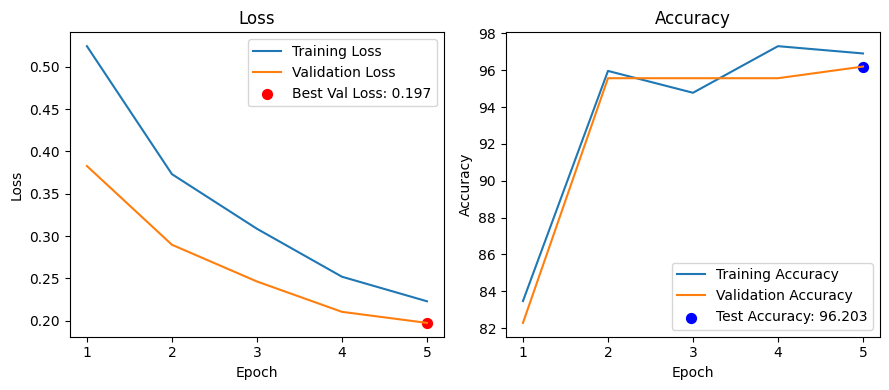

In [ ]:
plot_results(train_losses, validation_losses, train_accuracies, validation_accuracies, test_accuracy, best_val_loss, best_epoch=best_epoch)

##### Evaluation metrics: classification report, confusion matrix, and ROC curve.

In [ ]:
test_predictions, test_probs, test_labels = get_predictions_and_labels(model, test_dataloader, device)

metrics = calculate_evaluation_metrics(
    test_labels, test_predictions, test_probs,
    output_dir='files', label_name=label_col, save_figures=True,
)

uncertain_flags = flag_uncertain(test_probs)
print(f"\nUncertain predictions (0.3-0.7): {sum(uncertain_flags)} / {len(uncertain_flags)}")

Evaluating: 100%|██████████| 20/20 [00:01<00:00, 19.36it/s]


EVALUATION METRICS: SINGLE_CASE
              precision    recall  f1-score   support

     Exclude      1.000     0.739     0.850        23
     Include      0.957     1.000     0.978       135

    accuracy                          0.962       158
   macro avg      0.979     0.870     0.914       158
weighted avg      0.964     0.962     0.960       158

Key Metrics:
  accuracy: 0.962
  precision: 0.957
  recall: 1.000
  specificity: 0.739
  f1_score: 0.978
  roc_auc: 0.867

Confusion matrix saved: files/confusion_matrix_single_case.png
ROC curve saved: files/roc_curve_single_case.png

Uncertain predictions (0.3-0.7): 17 / 158


Cross-validation for reliable performance estimates.

In [ ]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

cv_results = cross_validate(
    df, tokenizer, device, column_specifications, numeric_transform, config,
    numeric_cols_num=1, output_size=1, output_dir='files/cv',
)

logging.getLogger("transformers").setLevel(logging.WARNING)
warnings.filters = [f for f in warnings.filters if not (f[2] is UserWarning)]

print(f"\nMean F1: {cv_results['mean_metrics']['f1_score']:.3f} ± {cv_results['std_metrics']['f1_score']:.3f}")
print(f"Mean ROC AUC: {cv_results['mean_metrics']['roc_auc']:.3f} ± {cv_results['std_metrics']['roc_auc']:.3f}")

##### Calibrate model probabilities via temperature scaling.

In [ ]:
calibration = calibrate_model(model, validation_dataloader, device)
print(f"Temperature: {calibration.temperature:.3f}")

Temperature: 0.896


##### Filter rows where "single_case" is NA (not labeled).

In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')

labeled_data = pd.read_excel("files/labeled_data.xlsx")
init_all_data = pd.read_csv("files/init_all_data.csv")

missing_uts = set(labeled_data['UT']) - set(init_all_data['UT'])
if missing_uts:
    print(f"Removing {len(missing_uts)} rows from labeled_data; these UTs are not in init_all_data:\n{missing_uts}")
    labeled_data = labeled_data[labeled_data['UT'].isin(init_all_data['UT'])]

init_all_data = pd.merge(init_all_data, labeled_data, on="UT", how="left", suffixes=("", "_y"))
init_all_data = init_all_data.loc[:, ~init_all_data.columns.str.endswith("_y")]
init_all_data.columns = init_all_data.columns.str.replace("_x$", "", regex=True)

unlabeled_data = init_all_data[pd.isna(init_all_data["single_case"])]
unlabeled_data.to_excel("files/unlabeled_data.xlsx", index=False)
print(f"Unlabeled data: {len(unlabeled_data)} records saved to files/unlabeled_data.xlsx")

unlabeled_data = pd.read_excel("files/unlabeled_data.xlsx")

Unlabeled data: 4349 records saved to files/unlabeled_data.xlsx


In [ ]:
unlabeled_df = unlabeled_data[['UT', 'single_case', 'technology_use', 'SO', 'PY', 'AF', 'TI', 'AB', 'DE']].copy()
unlabeled_df["PY"] = pd.to_numeric(unlabeled_df["PY"], errors="coerce")

missing_values = unlabeled_df.isnull().sum()
print(missing_values)

UT                   0
single_case       4349
technology_use    4349
SO                   0
PY                   0
AF                   0
TI                   0
AB                 129
DE                 912
dtype: int64


##### Load the BERT tokenizer.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(config.model_name)

##### Preprocess and create dataloaders.

In [ ]:
column_specifications = {
    "text_cols": ['AF', 'TI', 'AB', 'DE'],
    "categorical_cols": ['SO'],
    "numeric_cols": ['PY'],
    "label_col": "single_case",
}

numeric_transform = {'PY': 'min'}
label_col = column_specifications['label_col']

# Apply fitted transforms from training (no data leakage)
unlabeled_dataset, _ = preprocess_dataset(
    unlabeled_df, tokenizer, device, column_specifications, numeric_transform,
    max_length=config.max_length, fitted_transforms=fitted,
)
unlabeled_dataloader = create_dataloader(unlabeled_dataset, SequentialSampler, config.eval_batch_size)

##### Load and initialize the PubMLP model.

In [ ]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

model = PubMLP(
    categorical_vocab_sizes=fitted.categorical_vocab_sizes,
    numeric_cols_num=1,
    mlp_hidden_size=config.mlp_hidden_size,
    output_size=1,
    dropout_rate=config.dropout_rate,
    embedding_model=config.embedding_model,
    model_name=config.model_name,
    n_hidden_layers=config.n_hidden_layers,
).to(device)

logging.getLogger("transformers").setLevel(logging.WARNING)

model.load_state_dict(torch.load(f"best_model_state_{label_col}.pth", map_location=device))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

<All keys matched successfully>

##### Predict each publication.

In [ ]:
predictions, probabilities = predict_model(model, unlabeled_dataloader, device, calibration=calibration)

uncertain = flag_uncertain(probabilities, low=config.uncertainty_low, high=config.uncertainty_high)
print(f"Uncertain predictions ({config.uncertainty_low}-{config.uncertainty_high}): {sum(uncertain)} / {len(uncertain)}")

predictions_data = pd.DataFrame({
    label_col: ['Yes' if p == 1 else 'No' for p in predictions],
    'probability': probabilities,
    'uncertain': uncertain,
})

if len(predictions_data) == len(unlabeled_df):
    unlabeled_df[label_col] = predictions_data[label_col].values
    unlabeled_df['probability'] = predictions_data['probability'].values
    unlabeled_df['uncertain'] = predictions_data['uncertain'].values
    predicted_data = unlabeled_df
else:
    print("The number of rows in predictions_df and unlabeled_df does not match.")

predicted_file = f"files/predicted_data_{label_col}.xlsx"
predicted_data.to_excel(predicted_file, index=False)
print(f"Data saved to {predicted_file}")

screened_pubs = (predicted_data[label_col] == 'Yes').sum()
print(f"'Yes' predictions for {label_col}: {screened_pubs}")

Predicting: 100%|██████████| 544/544 [00:27<00:00, 19.78it/s]


Uncertain predictions (0.3-0.7): 1859 / 4349
Data saved to files/predicted_data_single_case.xlsx
'Yes' predictions for single_case: 2506


In [ ]:
all_data = pd.merge(predicted_data, init_all_data, on="UT", how="left", suffixes=("", "_y"))
all_data = all_data.loc[:, ~all_data.columns.str.endswith("_y")]
all_data.columns = all_data.columns.str.replace("_x$", "", regex=True)

all_data_file = f"files/all_data_{label_col}.xlsx"
all_data.to_excel(all_data_file, index=False)
print(f"Data saved to {all_data_file}")

Data saved to files/all_data_single_case.xlsx


In [23]:
from nbconvert import HTMLExporter
import nbformat

notebook_path = 'index.ipynb'
html_exporter = HTMLExporter()

with open(notebook_path, 'r', encoding='utf-8') as nb_file:
    notebook_content = nb_file.read()
    notebook = nbformat.reads(notebook_content, as_version=4)

if 'widgets' in notebook.metadata and 'application/vnd.jupyter.widget-state+json' in notebook.metadata['widgets']:
    if 'state' not in notebook.metadata['widgets']['application/vnd.jupyter.widget-state+json']:
        notebook.metadata['widgets']['application/vnd.jupyter.widget-state+json']['state'] = {}

html_output, _ = html_exporter.from_notebook_node(notebook)

with open('index.html', 'w', encoding='utf-8') as html_file:
    html_file.write(html_output)